# Radar Spline Fitting with Sensor Fusion

This notebook performs B-Spline trajectory estimation by fusing Radar Doppler data and IMU acceleration data.

## Objectives
1.  Load Radar and IMU data from ROS bag.
2.  Apply time synchronization correction.
3.  Fit a B-Spline trajectory using Joint Optimization (Doppler + Accelerometer).
4.  Visualize the results.

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
import os

# Add analysis directory to path
sys.path.append(os.path.abspath('..'))

from rosbag_loader import loader
from radar_velocity_utils import solve_ego_velocity_weighted, integrate_imu_acceleration

%matplotlib inline

## Configuration

In [54]:
BAG_PATH = r"C:\Users\luchs\MyData\Education\Master_TUM\25WS\Guided Research\radar-iwr6843-driver\rosbags\2025-12-17-16-02-22.bag"

# Time window selection (same as 02_radar_time_sync)
START_TIME_OFFSET = 31.5  # Skip first N seconds
DURATION = 15.0           # Analyze this many seconds

# Time Synchronization
TIME_SHIFT_DT = -0.018879375900920006 

# Spline Configuration
SPLINE_ORDER = 6  # Cubic B-Spline (k=4)
KNOT_SPACING = 0.2 # Seconds between knots

# Optimization Weights
WEIGHT_ACCEL = 0.01
REGULARIZATION_LAMBDA = 0.2

## 1. Data Loading

In [55]:
print(f"Loading bag: {BAG_PATH}")
TOPIC_IMU = '/angrybird2/imu'
TOPIC_RADAR = '/ti_mmwave/radar_scan_pcl_0'

data = loader.load_bag_topics(BAG_PATH, verbose=True)
print("Data loaded.")

t_start = data.start_time + START_TIME_OFFSET
t_end = t_start + DURATION
data.imu_data = [imu for imu in data.imu_data if t_start <= imu.timestamp <= t_end]
data.radar_velocity = [radar for radar in data.radar_velocity if t_start <= radar.timestamp <= t_end]

print(f"IMU messages: {len(data.imu_data)}")
print(f"Radar messages: {len(data.radar_velocity)}")

Loading bag: C:\Users\luchs\MyData\Education\Master_TUM\25WS\Guided Research\radar-iwr6843-driver\rosbags\2025-12-17-16-02-22.bag

Loading rosbag: 2025-12-17-16-02-22.bag
Duration: 48.59s
  Loading /mocap/angrybird2/pose...
  Loading /mocap/angrybird2/accel...
  Loading /angrybird2/agiros_pilot/state...
  Loading /angrybird2/agiros_pilot/odometry...
  Loading /angrybird2/imu...
  Loading /ti_mmwave/radar_scan_pcl_0...
  Loading /mmWaveDataHdl/RScanVelocity...
  Done!

Data loaded.
IMU messages: 14917
Radar messages: 449


## 2. Preprocessing & Synchronization

In [56]:
data.radar_velocity[0].velocities

array([ 0.60434902,  0.60434902, -0.60434902])

In [57]:
# Extract IMU Data
imu_t = []
imu_acc_x = []
imu_acc_y = []

imu_df = pd.DataFrame([imu.to_dict() for imu in data.imu_data])
imu_df.head()

imu_t = np.array(imu_df['timestamp'])
imu_acc_x = np.array(imu_df['ax'])
imu_acc_y = np.array(imu_df['ay'])
t0 = imu_t[0]
imu_t = imu_t - t0

# Extract Radar Data
radar_t = []
radar_points = [] # List of (N, 5) arrays

for frame in data.radar_velocity:
    if frame.velocities is None or frame.positions is None:
        continue

    pts = []

    for i in range(len(frame.velocities)):

        x, y, z = frame.positions[i]
        v_dop = frame.velocities[i]
        intensity = frame.intensities[i] if frame.intensities is not None else 0
        pts.append(np.array([x,y,z,v_dop,intensity]))


    radar_points.append(np.array(pts))
    radar_t.append(frame.timestamp + TIME_SHIFT_DT - t0)


    
radar_t = np.array(radar_t)

print(f"IMU Time range: {imu_t.min():.2f} to {imu_t.max():.2f}")
print(f"Radar Time range: {radar_t.min():.2f} to {radar_t.max():.2f}")

IMU Time range: 0.00 to 15.00
Radar Time range: -0.00 to 14.96


## 3. B-Spline Basis Functions (Cox-de Boor)

We implement the Cox-de Boor recursion to evaluate B-Spline basis functions and their derivatives.

In [58]:
def cox_de_boor(t, i, k, knots):
    """
    Recursive Cox-de Boor algorithm.
    t: evaluation point (or array)
    i: index of basis function
    k: order (degree + 1)
    knots: knot vector
    """
    if k == 1:
        return np.where((t >= knots[i]) & (t < knots[i+1]), 1.0, 0.0)
    
    denom1 = knots[i+k-1] - knots[i]
    term1 = 0.0
    if denom1 > 0:
        term1 = ((t - knots[i]) / denom1) * cox_de_boor(t, i, k-1, knots)
        
    denom2 = knots[i+k] - knots[i+1]
    term2 = 0.0
    if denom2 > 0:
        term2 = ((knots[i+k] - t) / denom2) * cox_de_boor(t, i+1, k-1, knots)
        
    return term1 + term2

def spline_derivative(t, i, k, knots, deriv_order=1):
    """
    Computes derivative of B-spline basis.
    """
    if deriv_order == 0:
        return cox_de_boor(t, i, k, knots)
    
    # Standard derivative formula for B-splines
    # B'_{i,k}(t) = (k-1) * ( B_{i,k-1}/(t_{i+k-1}-t_i) - B_{i+1,k-1}/(t_{i+k}-t_{i+1}) )
    
    # Note: Using p = k-1 (degree)
    # The multiplier is the DEGREE, which is k-1.
    p = k - 1
    
    denom1 = knots[i+p] - knots[i]
    term1 = 0.0
    if denom1 > 0:
        # Recurse for lower order basis derivative if needed, 
        # but for 1st deriv of B_{i,k}, we need 0th deriv of B_{i,k-1}
        term1 = spline_derivative(t, i, k-1, knots, deriv_order-1) / denom1
        
    denom2 = knots[i+p+1] - knots[i+1]
    term2 = 0.0
    if denom2 > 0:
        term2 = spline_derivative(t, i+1, k-1, knots, deriv_order-1) / denom2
        
    return p * (term1 - term2)

## 4. Optimization Engine

We construct the stacked matrices for the joint optimization problem.

### Cost Function Terms
1.  **Doppler Velocity**: $v_{dop} = \dot{x} \frac{r_x}{r}$.
    *   $H_{vel, row} = [ \dots, \dot{B}_i(t) \cdot \frac{r_x}{r}, \dots ]$
2.  **Acceleration**: $a_x = \ddot{x}$.
    *   $H_{acc, row} = [ \dots, \ddot{B}_i(t), \dots ]$

In [51]:
# 1. Setup Knots and Control Points
t_min = imu_t.min()
t_max = imu_t.max()

# Determine number of knots
num_segments = int((t_max - t_min) / KNOT_SPACING) + 1
# Knots: Clamped at ends (repeat order times)
internal_knots = np.linspace(t_min, t_max, num_segments + 1)
# Add padding for clamped BSpline
knots = np.concatenate(([t_min]*(SPLINE_ORDER-1), internal_knots, [t_max]*(SPLINE_ORDER-1)))
num_control_points = len(knots) - SPLINE_ORDER
print(f"Number of Control Points: {num_control_points}")

# 2. Build Matrices
# We will have many rows. Lists to collect them.
H_rows = []
b_vals = []

# --- Doppler Term ---
print("Building Doppler Constraints...")
for i, t_frame in enumerate(radar_t):
    if t_frame < t_min or t_frame > t_max:
        continue
        
    # Get frame data
    pts = radar_points[i]
    if len(pts) == 0: continue
        
    x = pts[:, 0]
    y = pts[:, 1]
    z = pts[:, 2]
    v_dop = pts[:, 3]
    intensity = pts[:, 4]
    
    # Cosine theta for X-projection: rx / r
    r = np.sqrt(x**2 + y**2 + z**2)
    cos_theta = x / r
    
    # Evaluate Basis Derivatives at t_frame
   
    # Let's calculate the row for velocity: [B'_0, B'_1, ...]
    basis_vel = np.zeros(num_control_points)
    for cp_idx in range(num_control_points):
        if t_frame >= knots[cp_idx] and t_frame < knots[cp_idx+SPLINE_ORDER]:
             basis_vel[cp_idx] = spline_derivative(t_frame, cp_idx, SPLINE_ORDER, knots, deriv_order=1)
             
    # Add rows for each point
    # v_dop_j = (sum_k P_k * B'_k) * cos_theta_j
    # So row for P is: [B'_0 * cos_theta_j, B'_1 * cos_theta_j, ...]
    for j in range(len(v_dop)):
        row = basis_vel * cos_theta[j]
        H_rows.append(row)
        b_vals.append(v_dop[j])

# --- Acceleration Term ---
print("Building Acceleration Constraints...")
sqrt_w_acc = np.sqrt(WEIGHT_ACCEL)
for i, t_imu_val in enumerate(imu_t):
    if t_imu_val < t_min or t_imu_val > t_max: continue
        
    acc_x = imu_acc_x[i]
    
    # Evals for 2nd derivative
    basis_acc = np.zeros(num_control_points)
    for cp_idx in range(num_control_points):
        if t_imu_val >= knots[cp_idx] and t_imu_val < knots[cp_idx+SPLINE_ORDER]:
            basis_acc[cp_idx] = spline_derivative(t_imu_val, cp_idx, SPLINE_ORDER, knots, deriv_order=2)
            
    # Row: sqrt(w) * [B''_0, ...]
    H_rows.append(basis_acc * sqrt_w_acc)
    b_vals.append(acc_x * sqrt_w_acc)
    
# --- Regularization Term (Jerk) ---
print("Building Regularization...")
sqrt_lambda = np.sqrt(REGULARIZATION_LAMBDA)
# Sample regularization points (e.g. at knotos)
reg_times = internal_knots
for t_reg in reg_times:
    basis_jerk = np.zeros(num_control_points)
    for cp_idx in range(num_control_points):
        if t_reg >= knots[cp_idx] and t_reg < knots[cp_idx+SPLINE_ORDER]:
             basis_jerk[cp_idx] = spline_derivative(t_reg, cp_idx, SPLINE_ORDER, knots, deriv_order=3)
    
    H_rows.append(basis_jerk * sqrt_lambda)
    b_vals.append(0.0)

# Solve
H = np.array(H_rows)
b = np.array(b_vals)

print(f"Solving system shape: H={H.shape}, b={b.shape}")

# Using lstsq
control_points, residuals, rank, s = np.linalg.lstsq(H, b, rcond=None)
print("Solved Control Points.")

Number of Control Points: 80
Building Doppler Constraints...
Building Acceleration Constraints...
Building Regularization...
Solving system shape: H=(17459, 80), b=(17459,)
Solved Control Points.


## 5. Visualization

Reconstruct the trajectory and compare with measurements.

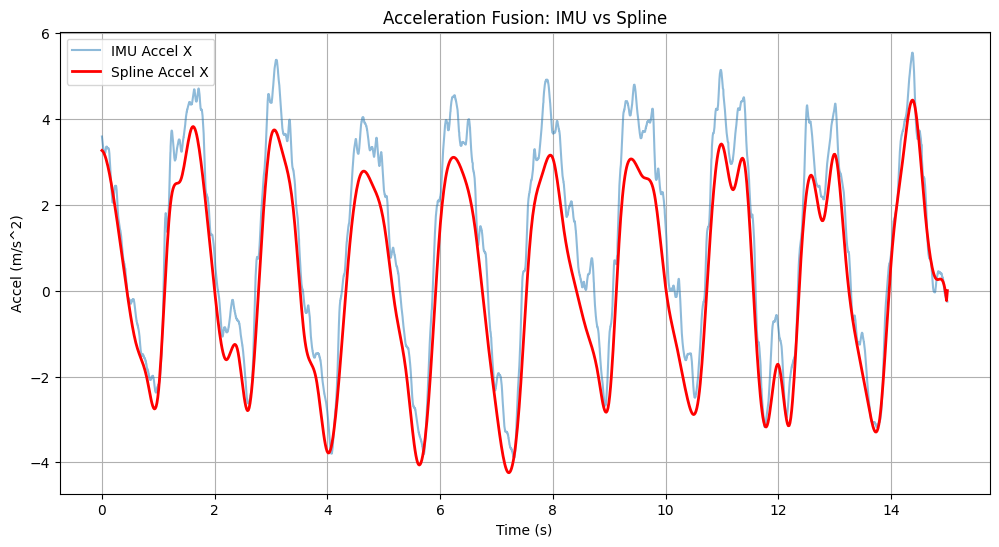

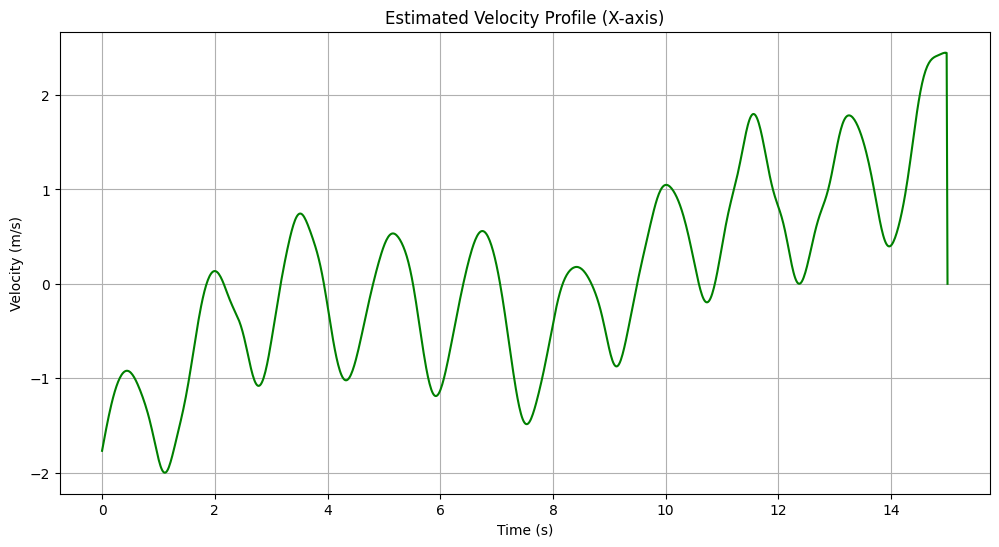

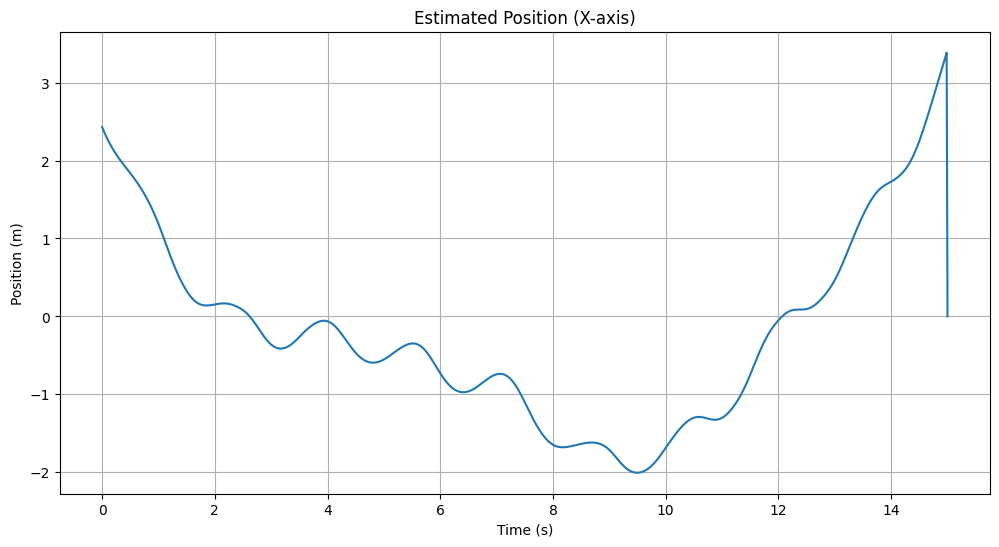

In [52]:
# Eval times
t_eval = np.linspace(t_min, t_max, 1000)
x_fit = np.zeros_like(t_eval)
v_fit = np.zeros_like(t_eval)
a_fit = np.zeros_like(t_eval)

for i, t in enumerate(t_eval):
    for cp_idx in range(num_control_points):
        # Check support
        if t >= knots[cp_idx] and t < knots[cp_idx+SPLINE_ORDER]:
            p = control_points[cp_idx]
            x_fit[i] += p * cox_de_boor(t, cp_idx, SPLINE_ORDER, knots)
            v_fit[i] += p * spline_derivative(t, cp_idx, SPLINE_ORDER, knots, deriv_order=1)
            a_fit[i] += p * spline_derivative(t, cp_idx, SPLINE_ORDER, knots, deriv_order=2)

# Plot Acceleration Comparison
plt.figure(figsize=(12, 6))
plt.plot(imu_t, imu_acc_x, label='IMU Accel X', alpha=0.5)
plt.plot(t_eval, a_fit, label='Spline Accel X', color='red', linewidth=2)
plt.title("Acceleration Fusion: IMU vs Spline")
plt.xlabel("Time (s)")
plt.ylabel("Accel (m/s^2)")
plt.legend()
plt.grid(True)
plt.show()

# Plot Velocity
plt.figure(figsize=(12, 6))
# Overlay Radar Doppler component clouds? 
# Hard to verify exact velocity from cloud without Ego fit, but we can see trend.
plt.plot(t_eval, v_fit, label='Spline Velocity X', color='green')
plt.title("Estimated Velocity Profile (X-axis)")
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.grid(True)
plt.show()

# Plot Trajectory
plt.figure(figsize=(12, 6))
plt.plot(t_eval, x_fit, label='Spline Trajectory X')
plt.title("Estimated Position (X-axis)")
plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.grid(True)
plt.show()

# radar config wie haben die das gemacht?